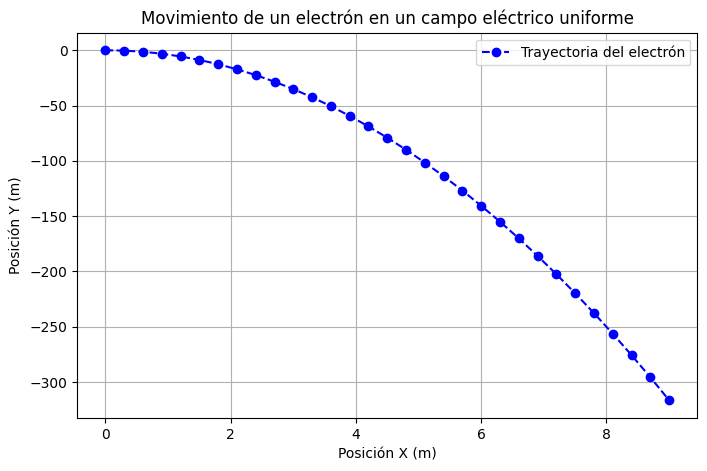

Tiempo (ns) | Posición X (m) | Posición Y (m)
         0 |    0.00000e+00 |   -0.00000e+00
       100 |    3.00000e-01 |   -3.51740e-01
       200 |    6.00000e-01 |   -1.40696e+00
       300 |    9.00000e-01 |   -3.16566e+00
       400 |    1.20000e+00 |   -5.62784e+00
       500 |    1.50000e+00 |   -8.79350e+00
       600 |    1.80000e+00 |   -1.26626e+01
       700 |    2.10000e+00 |   -1.72353e+01
       800 |    2.40000e+00 |   -2.25114e+01
       900 |    2.70000e+00 |   -2.84909e+01
      1000 |    3.00000e+00 |   -3.51740e+01
      1100 |    3.30000e+00 |   -4.25605e+01
      1200 |    3.60000e+00 |   -5.06506e+01
      1300 |    3.90000e+00 |   -5.94441e+01
      1400 |    4.20000e+00 |   -6.89410e+01
      1500 |    4.50000e+00 |   -7.91415e+01
      1600 |    4.80000e+00 |   -9.00454e+01
      1700 |    5.10000e+00 |   -1.01653e+02
      1800 |    5.40000e+00 |   -1.13964e+02
      1900 |    5.70000e+00 |   -1.26978e+02
      2000 |    6.00000e+00 |   -1.40696e+02
      210

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Constantes
q_e = -1.602e-19  # Carga del electrón (C)
m_e = 9.109e-31   # Masa del electrón (kg)
v0_x = 3e6        # Velocidad horizontal (m/s) [cite: 3]
E_field = 400     # Campo eléctrico hacia arriba (N/C) [cite: 3]

# Tiempo: 0 a 3000 ns con pasos de 100 ns
t = np.arange(0, 3100e-9, 100e-9)

# Aceleración (F = qE -> a = qE/m)
# Como E es hacia arriba (+) y q es negativa, la aceleración es hacia abajo (-)
ay = (q_e * E_field) / m_e

# Posiciones
x = v0_x * t
y = 0.5 * ay * t**2

# Gráfica (Figura 1)
plt.figure(figsize=(8, 5))
plt.plot(x, y, 'bo--', label='Trayectoria del electrón')
plt.title("Movimiento de un electrón en un campo eléctrico uniforme")
plt.xlabel("Posición X (m)")
plt.ylabel("Posición Y (m)")
plt.grid(True)
plt.legend()
plt.show()

# Mostrar tabla de posiciones
print("Tiempo (ns) | Posición X (m) | Posición Y (m)")
for i in range(len(t)):
    print(f"{t[i]*1e9:10.0f} | {x[i]:14.5e} | {y[i]:14.5e}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Parámetros (igual que el ejercicio anterior)
q_e, m_e, v0_x, E_field = -1.602e-19, 9.109e-31, 3e6, 400
t = np.arange(0, 3100e-9, 100e-9)
ay = (q_e * E_field) / m_e
x = v0_x * t
y = 0.5 * ay * t**2

# Configuración de la figura para animar
fig, ax = plt.subplots()
ax.set_xlim(0, max(x)*1.1)
ax.set_ylim(min(y)*1.1, 5)
line, = ax.plot([], [], 'bo', ms=5)
ax.set_title("Animación: Movimiento del Electrón")
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(x[:frame], y[:frame])
    return line,

# Crear animación
ani = FuncAnimation(fig, update, frames=len(t), init_func=init, blit=True)
plt.close() # Evita que se muestre la figura estática

# Mostrar como HTML5 en Colab
HTML(ani.to_html5_video())